# Notebook 3: Weather and Climate Forecasting


This notebook builds simple baseline forecasting models to estimate short-term temperature and rainfall trends using historical daily weather data.

The goal is to support the forecasting section of the final Streamlit dashboard.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load the dataset
df = pd.read_csv("C:/Projects/15_Climate_Risk_weather_Trends/data/processed/climate_weather_processed.csv")
df.head()

,date,temperature_avg,temperature_max,temperature_min,rainfall,humidity,wind_speed,solar_radiation,city,country,...,season,heat_risk_day,very_hot_day,heavy_rain_day,dry_day,temperature_range,rainfall_category,temperature_category,daily_climate_risk_score,risk_level
0,2020-01-01,22.56,29.21,17.90,4.79,64.14,2.21,9.34,Mandalay,Myanmar,...,Cool Season,0,0,0,0,11.31,Light Rain,Normal,0,Low
1,2020-01-02,22.87,30.14,17.65,0.76,66.13,2.17,9.82,Mandalay,Myanmar,...,Cool Season,0,0,0,1,12.49,Light Rain,Warm,10,Low
2,2020-01-03,21.56,26.78,17.90,9.95,75.17,2.04,9.07,Mandalay,Myanmar,...,Cool Season,0,0,0,0,8.88,Light Rain,Normal,0,Low
3,2020-01-04,21.44,27.62,18.01,6.08,79.23,2.31,9.21,Mandalay,Myanmar,...,Cool Season,0,0,0,0,9.61,Light Rain,Normal,0,Low
4,2020-01-05,21.10,26.91,17.26,9.39,79.46,3.25,10.89,Mandalay,Myanmar,...,Cool Season,0,0,0,0,9.65,Light Rain,Normal,0,Low


In [3]:
# Dataset Overview
print("Dataset shape:", df.shape)

print("\nAvailable cities:")
print(df["city"].unique())

print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (8768, 27)

Available cities:
['Mandalay' 'Naypyidaw' 'Singapore' 'Yangon']

Columns:
['date', 'temperature_avg', 'temperature_max', 'temperature_min', 'rainfall', 'humidity', 'wind_speed', 'solar_radiation', 'city', 'country', 'latitude', 'longitude', 'year', 'month', 'month_name', 'day', 'day_of_year', 'season', 'heat_risk_day', 'very_hot_day', 'heavy_rain_day', 'dry_day', 'temperature_range', 'rainfall_category', 'temperature_category', 'daily_climate_risk_score', 'risk_level']


In [4]:
# Convert date column
df["date"] = pd.to_datetime(df["date"])

print("Minimum date:", df["date"].min())
print("Maximum date:", df["date"].max())


Minimum date: 2020-01-01 00:00:00
Maximum date: 2025-12-31 00:00:00


## Forecasting for Yangon
For the first forecasting experiment, we select Yangon.
Starting with one city makes the forecasting process easier to test and understand before extending it to multiple cities.

In [5]:
selected_city = "Yangon"

city_df = df[df["city"] == selected_city].copy()

city_df = city_df.sort_values("date").reset_index(drop=True)

city_df.head()

,date,temperature_avg,temperature_max,temperature_min,rainfall,humidity,wind_speed,solar_radiation,city,country,...,season,heat_risk_day,very_hot_day,heavy_rain_day,dry_day,temperature_range,rainfall_category,temperature_category,daily_climate_risk_score,risk_level
0,2020-01-01,27.47,33.97,23.05,0.0,59.37,3.71,17.64,Yangon,Myanmar,...,Cool Season,0,0,0,1,10.92,NO Rain,Warm,10,Low
1,2020-01-02,27.69,34.70,21.93,0.0,59.48,3.02,17.51,Yangon,Myanmar,...,Cool Season,0,0,0,1,12.77,NO Rain,Warm,10,Low
2,2020-01-03,27.47,34.05,22.14,0.0,58.30,2.74,17.76,Yangon,Myanmar,...,Cool Season,0,0,0,1,11.91,NO Rain,Warm,10,Low
3,2020-01-04,27.49,35.18,20.60,0.0,56.99,2.32,17.82,Yangon,Myanmar,...,Cool Season,1,0,0,1,14.58,NO Rain,Hot,50,Moderate
4,2020-01-05,27.85,35.54,21.27,0.0,56.70,2.79,17.84,Yangon,Myanmar,...,Cool Season,1,0,0,1,14.27,NO Rain,Hot,50,Moderate


### Create Forecast Date Range

In this section, we create future dates for the next 6 months.

The forecast starts immediately after the last available historical date, allowing the observed climate trend and seasonal forecast to appear as a continuous timeline.

In [13]:
forecast_days = 365

forecast_start_date = city_df["date"].max() + pd.Timedelta(days=1)

future_dates = pd.date_range(
    start=forecast_start_date,
    periods=forecast_days
)

future_dates[:5]

DatetimeIndex(['2026-01-01', '2026-01-02', '2026-01-03', '2026-01-04',
               '2026-01-05'],
              dtype='datetime64[ns]', freq='D')

### Temperature Forecasting using Seasonal Baseline Method

In this section, we create a seasonal baseline forecast for average temperature.

Instead of using Linear Regression, this method estimates future temperature values based on historical average temperatures for the same month and day from previous years.

This approach is useful for climate and weather trend analysis because it captures seasonal fluctuation more naturally than a straight-line trend model.

In [14]:


future_temp_df = pd.DataFrame({
    "date": future_dates
})

future_temp_df["month"] = future_temp_df["date"].dt.month
future_temp_df["day"] = future_temp_df["date"].dt.day

historical_pattern = city_df.copy()
historical_pattern["month"] = historical_pattern["date"].dt.month
historical_pattern["day"] = historical_pattern["date"].dt.day

temperature_lookup = (
    historical_pattern
    .groupby(["month", "day"])["temperature_avg"]
    .mean()
    .reset_index()
)

future_temp_df = future_temp_df.merge(
    temperature_lookup,
    on=["month", "day"],
    how="left"
)

future_temp_df = future_temp_df.rename(
    columns={"temperature_avg": "forecast_temperature_avg"}
)

future_temp_df["city"] = selected_city

future_temp_df.head()


,date,month,day,forecast_temperature_avg,city
0,2026-01-01,1,1,25.240000,Yangon
1,2026-01-02,1,2,24.925000,Yangon
2,2026-01-03,1,3,24.993333,Yangon
3,2026-01-04,1,4,25.341667,Yangon
4,2026-01-05,1,5,25.871667,Yangon


### Plot Temperature Forecast
This plot compares historical average temperature with the next 6 months forecast.

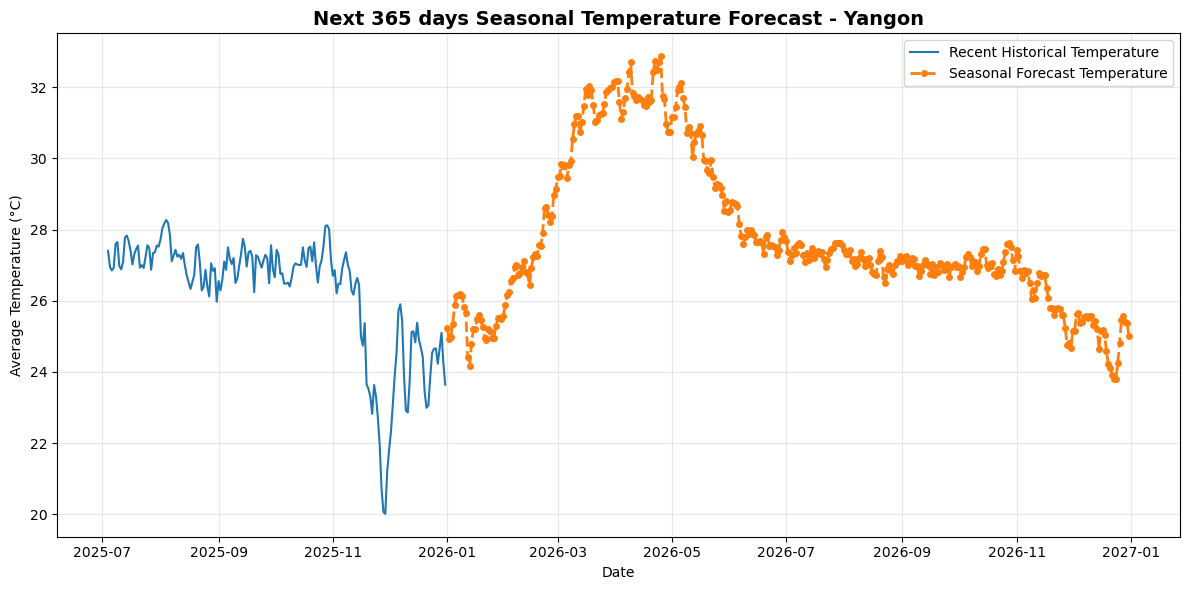

In [15]:
recent_history = city_df[
    city_df["date"] >= city_df["date"].max() - pd.Timedelta(days=180)
]

plt.figure(figsize=(12, 6))

plt.plot(
    recent_history["date"],
    recent_history["temperature_avg"],
    label="Recent Historical Temperature",
    linewidth=1.5
)

plt.plot(
    future_temp_df["date"],
    future_temp_df["forecast_temperature_avg"],
    label="Seasonal Forecast Temperature",
    linewidth=2,
    linestyle="--",
    marker="o",
    markersize=4
)

plt.title(f"Next 365 days Seasonal Temperature Forecast - {selected_city}", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Average Temperature (°C)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Rainfall Forecasting using Seasonal Baseline Method

Rainfall is highly variable and difficult to predict with a simple straight-line model.

In this section, future rainfall values are estimated using historical average rainfall for the same month and day from previous years.

This seasonal baseline approach helps capture rainy-season and dry-season patterns more naturally than Linear Regression.

## Generate Next 6 months Rainfall Forecast

We create future dates and use the trained model to estimate the next 6 months rainfall trend.

In [16]:
future_rain_df = pd.DataFrame({
    "date": future_dates
})

future_rain_df["month"] = future_rain_df["date"].dt.month
future_rain_df["day"] = future_rain_df["date"].dt.day

rainfall_lookup = (
    historical_pattern
    .groupby(["month", "day"])["rainfall"]
    .mean()
    .reset_index()
)

future_rain_df = future_rain_df.merge(
    rainfall_lookup,
    on=["month", "day"],
    how="left"
)

future_rain_df = future_rain_df.rename(
    columns={"rainfall": "forecast_rainfall"}
)

future_rain_df["forecast_rainfall"] = future_rain_df["forecast_rainfall"].clip(lower=0)
future_rain_df["city"] = selected_city

future_rain_df.head()

,date,month,day,forecast_rainfall,city
0,2026-01-01,1,1,0.001667,Yangon
1,2026-01-02,1,2,0.000000,Yangon
2,2026-01-03,1,3,0.000000,Yangon
3,2026-01-04,1,4,0.000000,Yangon
4,2026-01-05,1,5,0.000000,Yangon


### Plot Rainfall Forecast

This plot compares historical rainfall with the next 6 months rainfall forecast.

The forecast should be interpreted as a simple trend estimate, not an exact weather prediction.

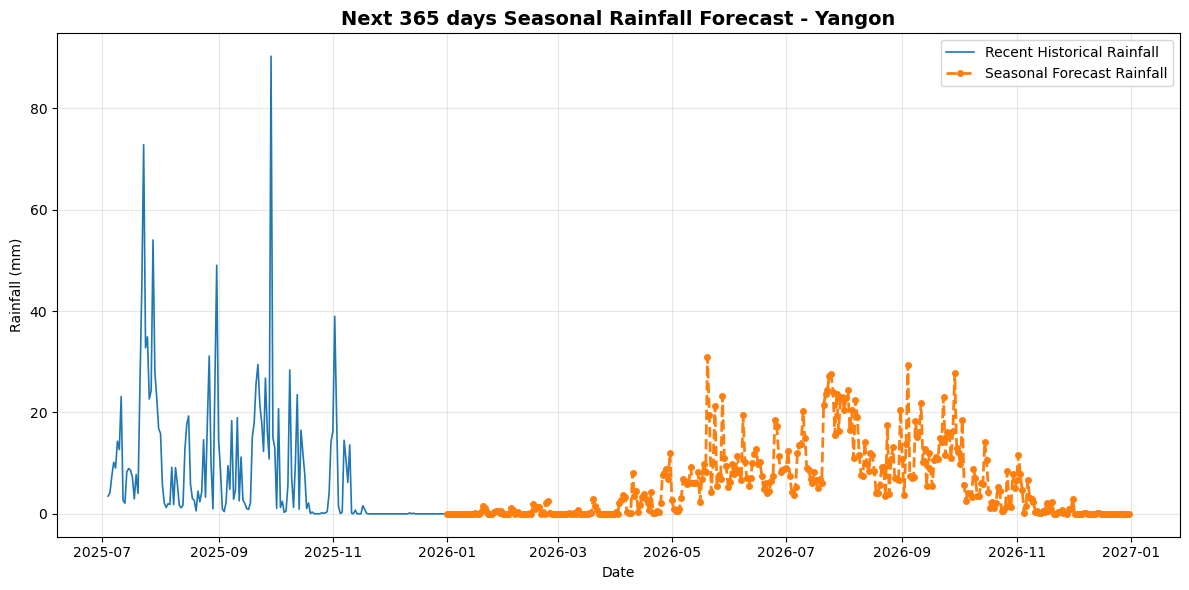

In [17]:
plt.figure(figsize=(12, 6))

plt.plot(
    recent_history["date"],
    recent_history["rainfall"],
    label="Recent Historical Rainfall",
    linewidth=1.2
)

plt.plot(
    future_rain_df["date"],
    future_rain_df["forecast_rainfall"],
    label="Seasonal Forecast Rainfall",
    linewidth=2,
    linestyle="--",
    marker="o",
    markersize=4
)

plt.title(f"Next 365 days Seasonal Rainfall Forecast - {selected_city}", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Seasonal Forecast Insight

The forecasting section uses a seasonal baseline method.

Future temperature and rainfall values are estimated using historical average values for the same month and day from previous years.

The blue line shows recent observed weather data, while the orange dashed line shows the next 365 days seasonal forecast.

This approach captures yearly seasonal fluctuation better than a simple Linear Regression model. However, the forecast should be interpreted as a climate-pattern estimate rather than an exact daily weather prediction.

### Save Forecast Results

The temperature and rainfall forecast outputs are saved as CSV files for later use in the Streamlit dashboard.

In [18]:
forecast_folder = "../data/processed/forecast"
os.makedirs(forecast_folder, exist_ok=True)

temperature_forecast_path = "../data/processed/forecast/temperature_forecast_yangon.csv"
rainfall_forecast_path = "../data/processed/forecast/rainfall_forecast_yangon.csv"

future_temp_df.to_csv(temperature_forecast_path, index=False)
future_rain_df.to_csv(rainfall_forecast_path, index=False)

print("Forecast files saved successfully!")
print("Temperature forecast:", temperature_forecast_path)
print("Rainfall forecast:", rainfall_forecast_path)

Forecast files saved successfully!
Temperature forecast: ../data/processed/forecast/temperature_forecast_yangon.csv
Rainfall forecast: ../data/processed/forecast/rainfall_forecast_yangon.csv


## Notebook Summary

In this notebook, seasonal baseline forecasting was used to estimate future temperature and rainfall patterns for Yangon.

Completed tasks:

- Loaded the processed climate dataset
- Selected Yangon for forecasting
- Created a future date range for the next 365 days
- Built a seasonal baseline temperature forecast
- Built a seasonal baseline rainfall forecast
- Visualized recent historical data and future seasonal forecasts
- Saved forecast outputs as CSV files

The seasonal baseline method estimates future values using historical averages for the same month and day. This helps capture natural seasonal fluctuation, making it more suitable for climate-pattern forecasting than a simple straight-line Linear Regression model.

The forecast should be interpreted as a climate-pattern estimate, not an exact real-time weather prediction.